# Linear Regression

## A Day in the Life of Chicago’s Taxi Network

Imagine standing on a busy street in Chicago on a cold morning. The city is just waking up, but thousands of yellow taxis are already in motion—each one carrying a story.

Every ride begins with a decision. A passenger waves down a cab or books one through a dispatch system. The driver starts the meter. At that exact moment, a digital footprint is created: the Trip ID, the Taxi ID, and the Trip Start Time.

As the taxi moves through the city—past skyscrapers, neighborhoods, and intersections—it accumulates data: how far it travels (Trip Miles), how long the journey lasts (Trip Seconds), and where it started and ended. Some trips are short—just a quick ride across a neighborhood. Others stretch across the city, weaving through traffic and toll roads.

At the end of the trip, another set of decisions is made. How much does the passenger pay? Do they leave a tip? Do they pay with cash or card? All of this becomes part of the dataset: Fare, Tips, Tolls, Extras, and Total Cost.

Behind the scenes, the city tracks all this information—not to watch individuals, but to understand patterns:

- Which areas are busiest?
- When do people travel the most?
- Which companies operate the most taxis?
- Where are the gaps in transportation?

Over time, these individual trips—thousands each day—form a massive network of movement across Chicago. What looks like random activity is actually full of patterns waiting to be discovered.

![taxi](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*p5J5Yvcd7PMfq5dA.jpg)

# Data Dictionary

1. `Trip ID` : A unique identifier for each trip, facilitating easy tracking and analysis.

2. `Taxi ID` : An identifier for the taxi involved in each trip, enabling tracking of individual vehicles.

3. `Trip Start Timestamp` : When the trip started, rounded to the nearest 15 minutes.

4. `Trip End Timestamp` : When the trip ended, rounded to the nearest 15 minutes.

5. `Trip Seconds` : Time of the trip in seconds.

6. Trip Miles` : Distance of the trip in miles.

7. `Pickup Census Tract` : The Census Tract where the trip began. For privacy, this Census Tract is not shown for some trips. This column often will be blank for locations outside Chicago.

8. `Dropoff Census Tract` : The Census Tract where the trip ended. For privacy, this Census Tract is not shown for some trips. This column often will be blank for locations outside Chicago.

9. `Pickup Community Area` : The Community Area where the trip began. This column will be blank for locations outside Chicago.

10. `Dropoff Community Area` : The Community Area where the trip ended. This column will be blank for locations outside Chicago.

11. `Fare` : The fare for the trip.

12. `Tips` : The tip for the trip. Cash tips generally will not be recorded.

13. `Tolls` : The tolls for the trip.

14. `Extras` : Extra charges for the trip.

15. `Trip Total`: Total cost of the trip, the total of the previous columns.

16. `Payment Type` : Type of payment for the trip.

17. `Company` : The taxi company.

### Load the `Chicago Taxi` dataset calling it `taxi`

- Clean the column headers. Call it `taxi_clean`
- What is the maximum fare? Call it `max_fare`
- What is the mean distance across all trips? Call it `mean_distance`
- How many cab companies are in the dataset? Call it `cab_companies`
- What is the most frequent payment type? Call it `payment_method`
- Are any features missing data? Call it `taxi_missing`

In [2]:
# YOUR CODE HERE
import pandas as pd
taxi=pd.read_csv("chicago_taxi_train.csv")
taxi.head()

#raise NotImplementedError()

,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [3]:
taxi_clean=taxi.rename(columns=str.lower)
taxi_clean.head()

,trip_start_timestamp,trip_end_timestamp,trip_start_hour,trip_seconds,trip_miles,trip_speed,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tip_rate,tolls,extras,trip_total,payment_type,company
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [4]:
taxi_clean.isna().sum()

trip_start_timestamp          0
trip_end_timestamp            0
trip_start_hour               0
trip_seconds                  0
trip_miles                    0
trip_speed                    0
pickup_census_tract       18435
dropoff_census_tract      17671
pickup_community_area      3217
dropoff_community_area     3495
fare                          0
tips                          0
tip_rate                      0
tolls                         0
extras                        0
trip_total                    0
payment_type                  0
company                       0
dtype: int64

In [5]:
Taxi_clean=taxi_clean.dropna()

In [6]:
max_fare = Taxi_clean["fare"].max()
max_fare

120.0

In [7]:
mean_distance=Taxi_clean["trip_miles"].mean()
mean_distance

np.float64(7.013493540881009)

### Correlation Matrix

If you have ever taken a taxi ride before, your experience is probably telling you that the fare is typically associated with the distance traveled and the duration of the trip. But, is there a way for you to learn more about how well these features correlate to the fare (label)?

In this step, you will use a correlation matrix to identify features whose values correlate well with the label. Correlation values have the following meanings:

`1.0:` perfect positive correlation; that is, when one attribute rises, the other attribute rises.

`-1.0:` perfect negative correlation; that is, when one attribute rises, the other attribute falls.

`0.0:` no correlation; the two columns are not linearly related.

- Calculate the corelation for all the numeric variables. Call it `taxi_cor`
- Which feature correlates most strongly to the label `FARE`? Call it `strongly_cor`
- Which feature correlates least strongly to the label `FARE`? Call it `least_cor`

In [8]:
# YOUR CODE HERE
import numpy as np
import pandas as pd
import pingouin as pg 
#raise NotImplementedError()

In [9]:
taxi_cor=Taxi_clean.loc[:,"trip_start_hour":"trip_total"].corr()
taxi_cor

,trip_start_hour,trip_seconds,trip_miles,trip_speed,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tip_rate,tolls,extras,trip_total
trip_start_hour,1.000000,0.005863,-0.004997,-0.004841,0.084194,-0.171418,0.039089,-0.157486,0.003055,0.024048,0.035370,0.004065,0.061465,0.012691
trip_seconds,0.005863,1.000000,0.883401,0.523244,0.505269,0.177070,0.620634,0.281037,0.904179,0.627248,-0.063957,0.005216,0.528153,0.883799
trip_miles,-0.004997,0.883401,1.000000,0.833990,0.601103,0.195978,0.737925,0.309766,0.989482,0.718412,-0.041142,0.030674,0.629174,0.979162
trip_speed,-0.004841,0.523244,0.833990,1.000000,0.537668,0.163750,0.646867,0.251512,0.801678,0.605707,-0.021341,0.045392,0.549030,0.802329
pickup_census_tract,0.084194,0.505269,0.601103,0.537668,1.000000,-0.067925,0.877449,-0.078281,0.595331,0.510223,0.031186,0.015745,0.540770,0.621529
dropoff_census_tract,-0.171418,0.177070,0.195978,0.163750,-0.067925,1.000000,-0.051675,0.779213,0.192336,0.091833,-0.021570,0.022177,-0.001149,0.168252
pickup_community_area,0.039089,0.620634,0.737925,0.646867,0.877449,-0.051675,1.000000,-0.065804,0.729634,0.607017,0.012190,0.018307,0.645844,0.756298
dropoff_community_area,-0.157486,0.281037,0.309766,0.251512,-0.078281,0.779213,-0.065804,1.000000,0.308838,0.135693,-0.046785,0.026356,0.026860,0.271093
fare,0.003055,0.904179,0.989482,0.801678,0.595331,0.192336,0.729634,0.308838,1.000000,0.715930,-0.047540,0.029021,0.619601,0.985735
tips,0.024048,0.627248,0.718412,0.605707,0.510223,0.091833,0.607017,0.135693,0.715930,1.000000,0.434356,0.041247,0.503277,0.804895


In [10]:
strongly_corr=taxi_cor["fare"].sort_values(ascending=False)
strongly_corr

fare                      1.000000
trip_miles                0.989482
trip_total                0.985735
trip_seconds              0.904179
trip_speed                0.801678
pickup_community_area     0.729634
tips                      0.715930
extras                    0.619601
pickup_census_tract       0.595331
dropoff_community_area    0.308838
dropoff_census_tract      0.192336
tolls                     0.029021
trip_start_hour           0.003055
tip_rate                 -0.047540
Name: fare, dtype: float64

In [11]:
least_corr=taxi_cor["fare"].sort_values(ascending=True)
least_corr

tip_rate                 -0.047540
trip_start_hour           0.003055
tolls                     0.029021
dropoff_census_tract      0.192336
dropoff_community_area    0.308838
pickup_census_tract       0.595331
extras                    0.619601
tips                      0.715930
pickup_community_area     0.729634
trip_speed                0.801678
trip_seconds              0.904179
trip_total                0.985735
trip_miles                0.989482
fare                      1.000000
Name: fare, dtype: float64

### Visualize relationships in dataset

Sometimes it is helpful to visualize relationships between features in a dataset; one way to do this is with a scatter plot.

Visualise:
- `fare` vs `trip_miles`, 
- `fare` vs `trip_seconds`

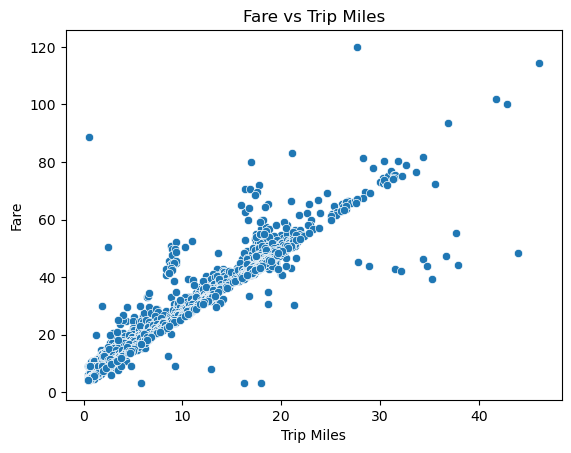

NotImplementedError: 

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="trip_miles",y="fare",data=Taxi_clean)
plt.xlabel("Trip Miles")
plt.ylabel("Fare")
plt.title("Fare vs Trip Miles")
plt.show()
raise NotImplementedError()

In [ ]:
# YOUR CODE HERE
import seaborn as sns
sns.scatterplot(x="trip_seconds",y="fare",data=Taxi_clean)
plt.xlabel("Trip Seconds")
plt.ylabel("Fare")
plt.title("Fare vs Trip Seconds")
plt.show()
raise NotImplementedError()

### Data Preprocessing

You will train a model to predict the cost of taxi fare

- Create a new column called `trip_minutes` from the column `trip_seconds`
- Select the following columns as your independent variables: `trip_minutes` and `trip_miles` calling it `X`
- Select `fare` as your dependent variable calling it `y`
- Split the data into training and testing data in the ratio 70% to 30%. Set the random state to 5


In [ ]:
# YOUR CODE HERE
Taxi_clean["trip_minutes"]=(Taxi_clean["trip_seconds"]/60).round(0)
Taxi_clean["trip_minutes"]
#raise NotImplementedError()

In [ ]:
Taxi_clean.head()

### Train a model with one feature

Build your model with one feature `trip_miles`.

What is the intercept?

What is the coefficient?

Write out your model

Interpret the result of the model

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# YOUR CODE HERE
independent_variables = Taxi_clean[["trip_minutes","trip_miles"]]
#independent_variable = Taxi_clean["trip_minutes"]
dependent_variable = Taxi_clean["fare"]
#raise NotImplementedError()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, test_size = 0.3, random_state = 5)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

In [ ]:
X_train.head()

In [ ]:
y_train.head()

**Trip_miles model**

In [ ]:
X_trip_miles = X_train[["trip_miles"]]

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
Taxi_clean_model = LinearRegression()

In [ ]:
Taxi_clean_model .fit(X_trip_miles, y_train)

### Evaluate your model

Use your training data to make predictions

Calculate
- RMSE call it `rmse`

- MAE call it `mae`

- R2 call it `r2`

- Residuals call it `residuals`

- Interpret the results

# Model Parameters

In [ ]:
Taxi_clean_model .intercept_
#raise NotImplementedError()

In [ ]:
pd.DataFrame(Taxi_clean_model.coef_, X_trip_miles.columns, ["Coefficient"])


# Model Formular for Prediction

#### fare = 4.68 + 2.28 * trip_miles

#  Model Evaluation

In [ ]:
fare_pred = Taxi_clean_model.predict(X_trip_miles)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
mse = mean_squared_error(y_train, fare_pred)
mse

In [ ]:
rmse = np.sqrt(mse)
rmse

In [ ]:
mae = mean_absolute_error(y_train, fare_pred)
mae

In [ ]:
r2 = r2_score(y_train, fare_pred)
r2

In [ ]:
residual1 = y_train - fare_pred


### Residual plot

Make a residual plot

In [ ]:
residual_plot = pd.DataFrame({"residual": residual1,
             "predicted": fare_pred})
#raise NotImplementedError()

In [ ]:
from plotnine import * 
(ggplot(residual_plot, aes( "predicted","residual"))
+ geom_point()
+ geom_hline(aes(yintercept = 0), color = "red", linetype = "--", size = 0.8)
+ theme_minimal())

### Train a model with two features
The model you trained with the feature `trip_miles` demonstrates fairly strong predictive power, but is it possible to do better? In this step, try training the model with two features, `trip_miles` and `trip_minutes`, to see if you can improve the model.

- Does the model with two features produce better results than one using a single feature?
- Interpret your findings.

In [ ]:


X_trip = X_train[["trip_miles","trip_minutes"]]
X_trip.head()
#raise NotImplementedError()

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
Taxi_clean_model2 = LinearRegression()

In [ ]:
Taxi_clean_model2 .fit(X_trip, y_train)

In [ ]:
Taxi_clean_model2.intercept_

In [ ]:
pd.DataFrame(Taxi_clean_model2.coef_, X_trip.columns, ["Coefficient"])

In [ ]:
import numpy as np
import statsmodels.api as sm

In [ ]:
X_trip_sm = sm.add_constant(X_trip)

trip_model = sm.OLS(y_train, X_trip_sm).fit()

trip_summary = trip_model.summary()

print(trip_summary)

# To get p-values and coefficients
p_values = trip_model.pvalues
coefficients = trip_model.params

print(p_values)
print(coefficients)

# Model Formular for Prediction

#### fare = 4.68 + 2.28 * trip_miles + 0.14  * trip_minutes

## Model Evaluation

In [ ]:
 Taxi_clean_model2_pred = Taxi_clean_model2.predict(X_trip)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
r2_score(y_train, Taxi_clean_model2_pred)

In [ ]:
mse = mean_squared_error(y_train, Taxi_clean_model2_pred)
mse

In [ ]:
rmse = np.sqrt(mse)
rmse

In [ ]:
mean_absolute_error(y_train,  Taxi_clean_model2_pred)

In [ ]:
residual2 = y_train - Taxi_clean_model2_pred

# Residual Plot

In [ ]:
from plotnine import *
import pandas as pd

In [ ]:
residual_plot = pd.DataFrame({"residual": residual2,
           "predicted": Taxi_clean_model2_pred})

In [ ]:
p = (ggplot(residual_plot, aes("Taxi_clean_model2_pred", "residual"))
+ geom_point()
+ geom_hline(aes(yintercept = 0), linetype = "--", size = 0.7, color = "red")
+ theme_minimal()
+ labs(y = "Residuals",
     x = "Predicted"))
p.save("my_plot.png")

## Interpretation of findings

 The model with two features  did not produce better results than one using a single feature.The residuals are not randomly scattered around the zero line.


### Use your best model to make predictions on the test data
Now that you have a trained model, you can use the model to make predictions. In practice, you should make predictions on test data that are not used during training. 

- Evaluate the predictions
- Make an Actual vs Predicted plot
- Interpret the plot

# Prediction with Test Data

In [ ]:
X2=X_train[["trip_minutes", "trip_miles", "payment_type"]]

In [ ]:
x_data = X_test[["trip_miles","trip_minutes","payment_type"]]


In [ ]:
test_pred =  Taxi_clean_model2.predict(x_data)

In [ ]:
test_pred[0:20]

In [ ]:
x_data["prediction"] = test_pred
x_data["fare"] = y_test



In [ ]:
x_data.info()

In [ ]:
p=(ggplot(x_data, aes("fare", "prediction", color = "payment_types"))
+ geom_point(size = 3)
+ geom_abline(color = "red", linetype = "--", size = 0.7)
+ scale_color_brewer("qual", palette = 5) 
+ theme_minimal())
p